In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

df = pd.read_csv('../data/application_train.csv')
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 325.2 MB


In [3]:
print(df['TARGET'].value_counts())
print()
print(df['TARGET'].value_counts(normalize=True).mul(100).round(2))

TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False).head(20)

,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


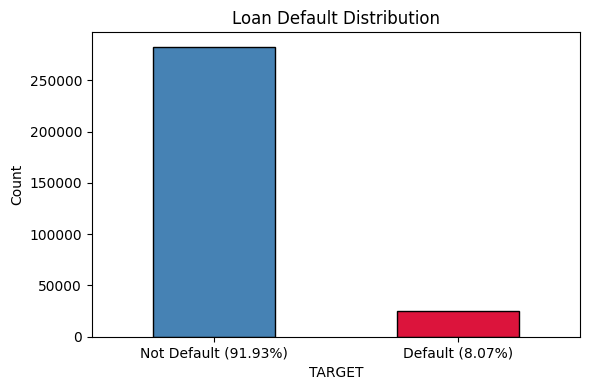

In [5]:
plt.figure(figsize=(6,4))
df['TARGET'].value_counts().plot(kind='bar', 
    color=['steelblue','crimson'], edgecolor='black')
plt.title('Loan Default Distribution')
plt.xticks([0,1], ['Not Default (91.93%)', 'Default (8.07%)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

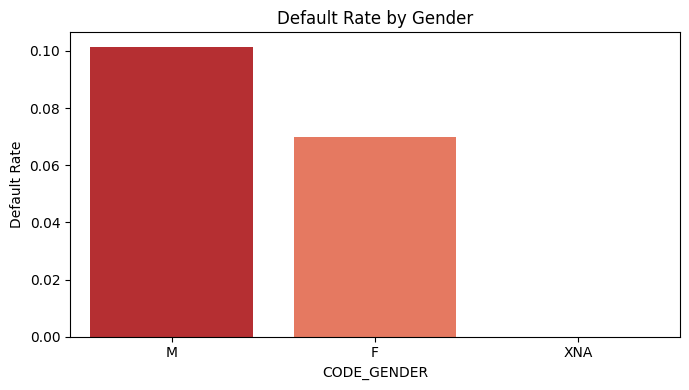

In [6]:
plt.figure(figsize=(7,4))
gender_default = df.groupby('CODE_GENDER')['TARGET'].mean().sort_values(ascending=False)
sns.barplot(x=gender_default.index, y=gender_default.values, palette='Reds_r')
plt.title('Default Rate by Gender')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

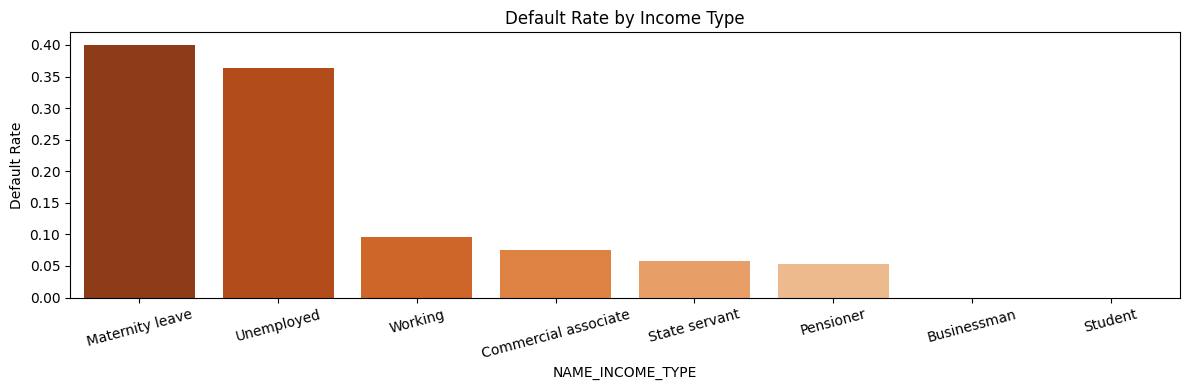

In [7]:
plt.figure(figsize=(12,4))
income_default = df.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values(ascending=False)
sns.barplot(x=income_default.index, y=income_default.values, palette='Oranges_r')
plt.title('Default Rate by Income Type')
plt.ylabel('Default Rate')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

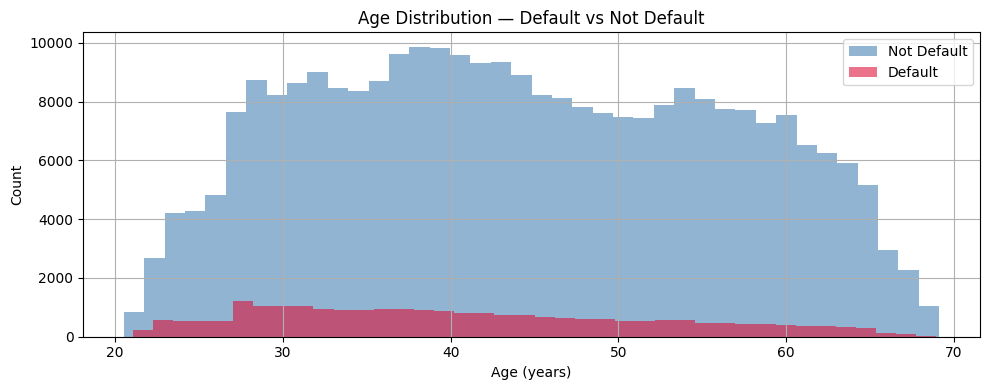

In [8]:
df['AGE_YEARS'] = df['DAYS_BIRTH'] / -365

plt.figure(figsize=(10,4))
df[df['TARGET']==0]['AGE_YEARS'].hist(bins=40, alpha=0.6, label='Not Default', color='steelblue')
df[df['TARGET']==1]['AGE_YEARS'].hist(bins=40, alpha=0.6, label='Default', color='crimson')
plt.legend()
plt.title('Age Distribution — Default vs Not Default')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

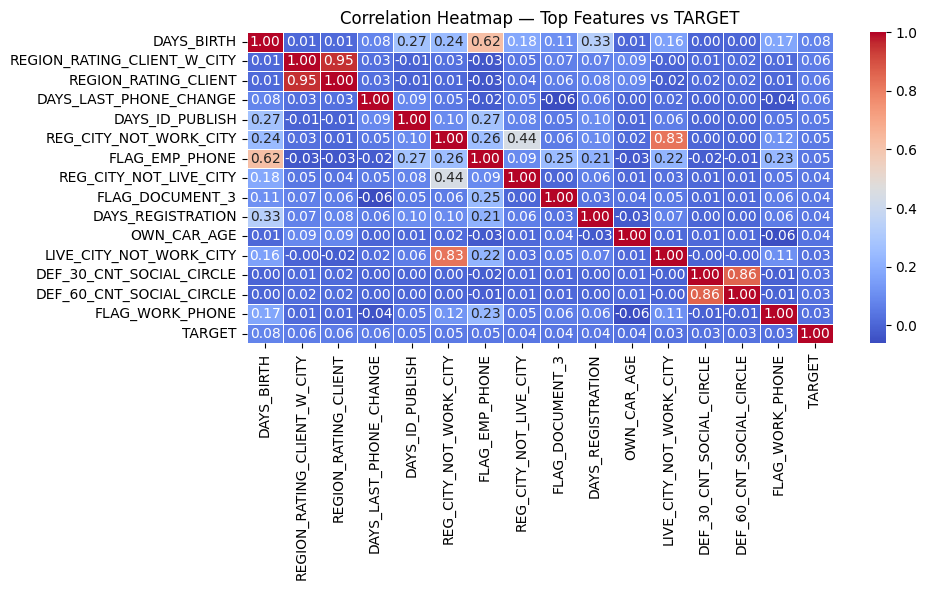

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

correlations = df[numeric_cols].corr()['TARGET'].sort_values(ascending=False)
top_features = correlations[1:16].index.tolist()  

plt.figure(figsize=(10,6))
sns.heatmap(df[top_features + ['TARGET']].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Top Features vs TARGET')
plt.tight_layout()
plt.show()

In [10]:
missing_pct = df.isnull().sum() / len(df) * 100
cols_to_drop = missing_pct[missing_pct > 40].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >40% missing")
df.drop(columns=cols_to_drop, inplace=True)


df.drop(columns=['SK_ID_CURR'], inplace=True)

print("Shape after dropping:", df.shape)

Dropping 49 columns with >40% missing
Shape after dropping: (307511, 73)


In [11]:
df['AGE_YEARS'] = df['DAYS_BIRTH'] / -365


df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, 0)
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / -365
df['YEARS_EMPLOYED'] = df['YEARS_EMPLOYED'].clip(lower=0)

df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)

df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)

df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + 1)

df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)

print("New features created!")
print(df[['AGE_YEARS', 'YEARS_EMPLOYED', 'CREDIT_INCOME_RATIO', 
          'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 
          'INCOME_PER_PERSON']].head())

New features created!
   AGE_YEARS  YEARS_EMPLOYED  CREDIT_INCOME_RATIO  ANNUITY_INCOME_RATIO  \
0  25.920548        1.745205             2.007879              0.121977   
1  45.931507        3.254795             4.790732              0.132216   
2  52.180822        0.616438             1.999970              0.099999   
3  52.068493        8.326027             2.316150              0.219898   
4  54.608219        8.323288             4.222187              0.179961   

   CREDIT_GOODS_RATIO  INCOME_PER_PERSON  
0            1.158394           101250.0  
1            1.145198            90000.0  
2            0.999993            33750.0  
3            1.052799            45000.0  
4            0.999998            60750.0  


In [12]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

print(f"Total features: {X.shape[1]}")
print(f"Categorical: {len(categorical_cols)}")
print(f"Numerical: {len(numerical_cols)}")
print(f"\nDefault rate: {y.mean():.3f}")

Total features: 77
Categorical: 12
Numerical: 65

Default rate: 0.081


In [13]:
cols_to_remove = ['DAYS_BIRTH', 'DAYS_EMPLOYED']
df.drop(columns=cols_to_remove, inplace=True)

X = df.drop('TARGET', axis=1)
y = df['TARGET']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Final feature count:", X.shape[1])
print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Final feature count: 75
Categorical: 12
Numerical: 63


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Default rate in train:", y_train.mean().round(3))
print("Default rate in test:", y_test.mean().round(3))

Train size: (246008, 75)
Test size: (61503, 75)
Default rate in train: 0.081
Default rate in test: 0.081


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print("Preprocessing pipeline ready!")

Preprocessing pipeline ready!


In [16]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, 
        class_weight='balanced', n_jobs=-1,
        min_samples_leaf=5), 
    
    'XGBoost': XGBClassifier(
        n_estimators=150, random_state=42,
        scale_pos_weight=11, 
        max_depth=6,         
        learning_rate=0.1,   
        eval_metric='logloss', verbosity=0),
    
    'LightGBM': LGBMClassifier(
        n_estimators=150, random_state=42,
        scale_pos_weight=11, 
        max_depth=6, 
        learning_rate=0.1, 
        verbose=-1)
}

results = {}

for name, model in models.items():
    print(f"=Training {name}=")
    
    
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results[name] = {'f1': f1, 'roc_auc': roc, 'pipeline': pipe}
    
   
    print(classification_report(y_test, y_pred, target_names=['Not Default', 'Default']))
    print(f"ROC-AUC Score: {roc:.3f}")
    print("\n" + "-"*40 + "\n")

=Training Logistic Regression=
              precision    recall  f1-score   support

 Not Default       0.96      0.69      0.80     56538
     Default       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503

ROC-AUC Score: 0.746

----------------------------------------

=Training Random Forest=
              precision    recall  f1-score   support

 Not Default       0.94      0.92      0.93     56538
     Default       0.26      0.31      0.29      4965

    accuracy                           0.87     61503
   macro avg       0.60      0.62      0.61     61503
weighted avg       0.88      0.87      0.88     61503

ROC-AUC Score: 0.747

----------------------------------------

=Training XGBoost=
              precision    recall  f1-score   support

 Not Default       0.96      0.73      0.83     56538
     Default       0.17      0.64 

In [17]:
for name, result in results.items():
    pipe = result['pipeline']
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    print(f"{name}:")
    print(f"  Predicted defaults: {y_pred.sum()} out of {len(y_pred)}")
    print(f"  Actual defaults: {y_test.sum()}")
    print(f"  Avg fraud probability: {y_prob.mean():.3f}")
    print()

Logistic Regression:
  Predicted defaults: 20883 out of 61503
  Actual defaults: 4965
  Avg fraud probability: 0.423

Random Forest:
  Predicted defaults: 5954 out of 61503
  Actual defaults: 4965
  Avg fraud probability: 0.295

XGBoost:
  Predicted defaults: 18202 out of 61503
  Actual defaults: 4965
  Avg fraud probability: 0.390

LightGBM:
  Predicted defaults: 18939 out of 61503
  Actual defaults: 4965
  Avg fraud probability: 0.395



In [18]:
from sklearn.model_selection import GridSearchCV

tuning_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        random_state=42,
        scale_pos_weight=11,
        verbose=-1))
])

param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__num_leaves': [31, 50],
}

grid_search = GridSearchCV(
    tuning_pipe,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 3))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 8, 'model__n_estimators': 200, 'model__num_leaves': 31}
Best CV ROC-AUC: 0.75


Tuned LightGBM → F1: 0.270 | ROC-AUC: 0.757

Classification Report:
              precision    recall  f1-score   support

 Not Default       0.96      0.71      0.82     56538
     Default       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.54     61503
weighted avg       0.90      0.71      0.77     61503



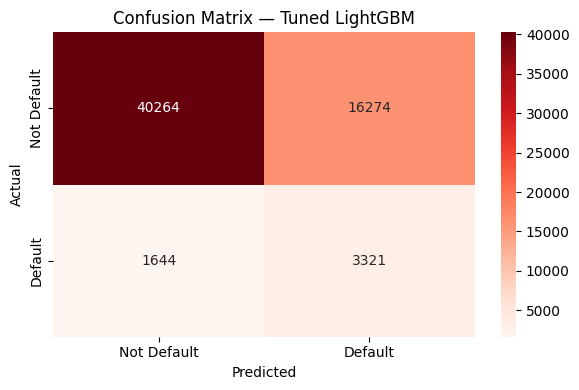

In [19]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

f1_tuned = f1_score(y_test, y_pred_tuned)
roc_tuned = roc_auc_score(y_test, y_prob_tuned)

print(f"Tuned LightGBM → F1: {f1_tuned:.3f} | ROC-AUC: {roc_tuned:.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned, 
      target_names=['Not Default', 'Default']))

from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Default', 'Default'],
            yticklabels=['Not Default', 'Default'])
plt.title('Confusion Matrix — Tuned LightGBM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import os

os.makedirs('../models', exist_ok=True)


joblib.dump(best_model, '../models/loan_default_model.pkl')
joblib.dump(categorical_cols, '../models/categorical_cols.pkl')
joblib.dump(numerical_cols, '../models/numerical_cols.pkl')

print("Model saved!")
print(os.listdir('../models'))

Model saved!
['categorical_cols.pkl', 'loan_default_model.pkl', 'numerical_cols.pkl']


In [21]:
import shap

lgbm_model = best_model.named_steps['model']
preprocessor_fitted = best_model.named_steps['preprocessor']

X_test_transformed = preprocessor_fitted.transform(X_test)

ohe_features = best_model.named_steps['preprocessor']\
    .named_transformers_['cat']['encoder']\
    .get_feature_names_out(categorical_cols).tolist()
all_features = numerical_cols + ohe_features

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_transformed)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("SHAP values computed!")
print("Shape:", shap_values.shape)

SHAP values computed!
Shape: (61503, 187)


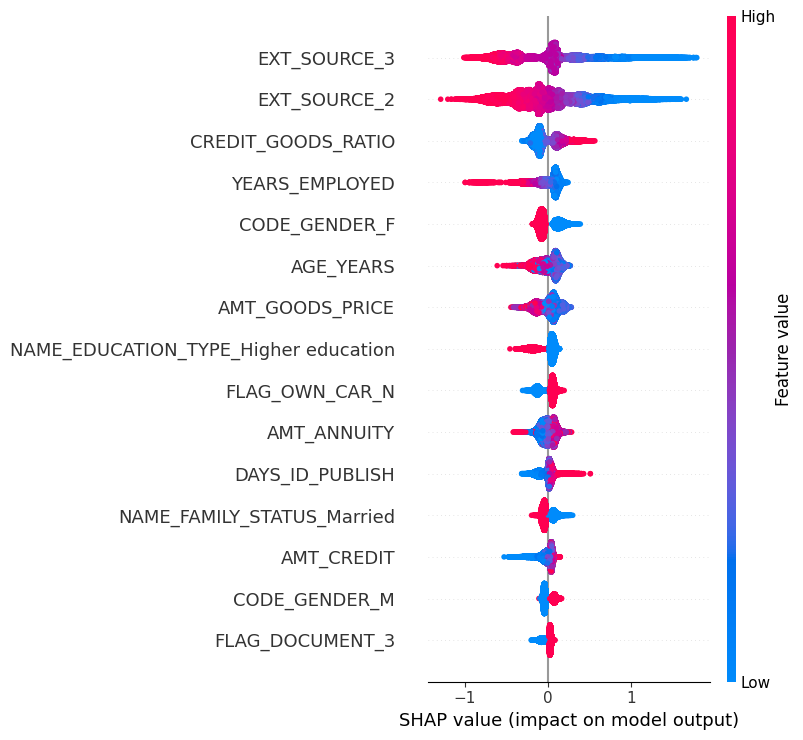

In [22]:
plt.figure()
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_features,
                  max_display=15)

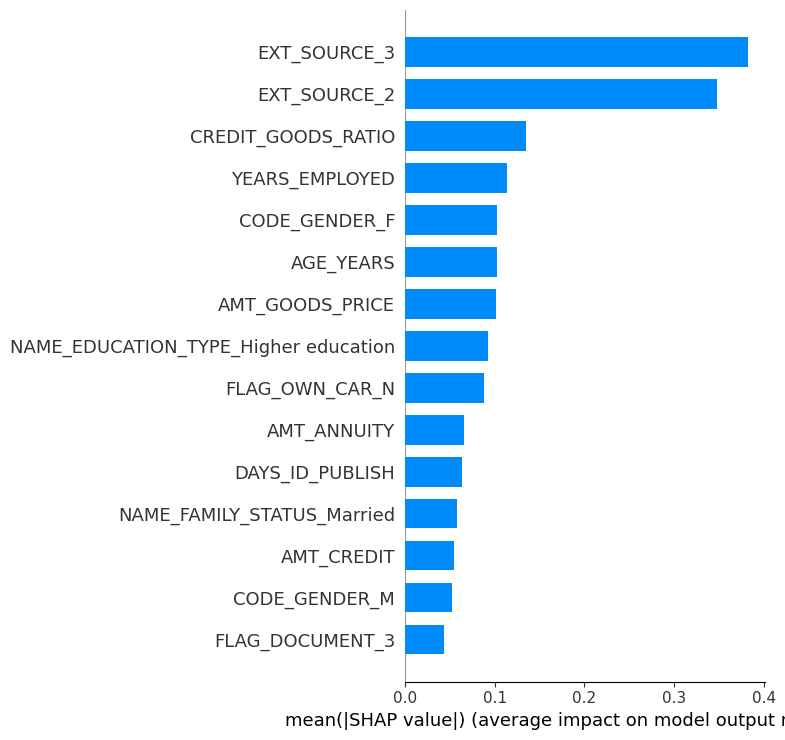

In [23]:
plt.figure()
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_features,
                  plot_type='bar',
                  max_display=15)